In [4]:
import numpy as np
from scipy.integrate import quad, simpson
from scipy.interpolate import InterpolatedUnivariateSpline, interp1d
from scipy.optimize import brentq
from numpy.polynomial.hermite import hermgauss

# ─────────────────────────────────────────
#  DATASET: (nombre, Z_daughter, Z_cluster, A_daughter, A_cluster,Q, G, beta)
# ─────────────────────────────────────────
nuclei = [
    
    ("Ra-222", 82,  6, 208, 14, 33.049, 68,  0.0648),
    ("Og-294", 82, 36, 208, 86, 304.31, 272, 0.01397)
    #("Cm-242", 82, 14, 208, 34, 96.509, 142, 0.0291)
]


# ─────────────────────────────────────────
#  CONSTANTES FIJAS
# ─────────────────────────────────────────

e2       = 1.44
a        = 0.54
x        = 7999 / 4
y        = 2134 / 2.5
J00      = -275
hbarc    = 197.327
hbar     = 6.582119569e-22
m_n      = 931.494
L        = 0


# Grillas globales
r_grid_c = np.linspace(0.01, 25,   2000)
r_grid_d = np.linspace(0.01, 25,   2000)
k_grid = np.linspace(0.0001, 30, 10000)
R_grid = np.linspace(0.01, 50,  5000)
#R_grid = np.linspace(0.01, 80,  5000)

# Transformada de Fourier del alfa (fija, no depende del núcleo hijo)


#-----------------------WHERE IS THE INTERCHANGE TERM ------------------------------------------------------------
g_NN = (x / (k_grid**2 + 4**2)) - (y / (k_grid**2 + 2.5**2)) #  (J00 / (4 * np.pi))

def sinc_safe(k, r):
    kr = k * r
    return np.where(kr == 0, 1.0, np.sin(kr) / kr)
#------------------------------------------------------------------------------------------------------------------

# ─────────────────────────────────────────
#  FUNCIÓN: busca λ óptimo y calcula tau
# ─────────────────────────────────────────
def compute_tau(V_nuc, V_C, V_L, Q, mu, B, label=""):

    def action(lam):
        V = lam * V_nuc + V_C + V_L
        s = InterpolatedUnivariateSpline(R_grid, Q - V, k=3)
        roots = s.roots()
        if len(roots) < 3:
            return None
        r1, r2, r3 = roots[0], roots[1], roots[2]
        I_val = quad(
            lambda r: np.sqrt(np.maximum((2*mu/hbarc**2) * s(r), 0)),
            r1, r2, limit=1000, points=[r1, r2],
            epsabs=1e-6, epsrel=1e-6
        )[0]
        return I_val, r1, r2, r3

    vals = []
    for lam in np.linspace(0.2, 2, 3000):
        res = action(lam)
        if res is not None:
            vals.append((lam, *res))

    if not vals:
        print(f"  [{label}] No se encontró λ válido.")
        return None

    lam_opt, _, r1_opt, r2_opt, r3_opt = min(vals, key=lambda v: abs(v[1] - B))

    V_fun = interp1d(R_grid, lam_opt * V_nuc + V_C + V_L,
                     kind='cubic', fill_value="extrapolate")

    I_G = quad(
        lambda r: np.sqrt((2*mu/hbarc**2) * np.maximum(V_fun(r) - Q, 0)),
        r2_opt, r3_opt, limit=200, points=[r2_opt, r3_opt],
        epsabs=1e-4, epsrel=1e-4
    )[0]

    I_f = quad(
        lambda r: 1 / np.sqrt((2*mu/hbarc**2) * np.abs(V_fun(r) - Q)),
        r1_opt, r2_opt, limit=200, points=[r1_opt, r2_opt],
        epsabs=1e-4, epsrel=1e-4
    )[0]

    N     = 1 / I_f
    P     = np.exp(-2 * I_G)
    Gamma = (hbarc**2 * P * N) / (2 * mu)
    tau   = (hbar * np.log(2)) / Gamma

    return tau, lam_opt, r1_opt, r2_opt, r3_opt, P, N


# ─────────────────────────────────────────
#  FUNCIÓN PRINCIPAL POR NÚCLEO
# ─────────────────────────────────────────
def compute_nucleus(name, Z_d, Z_c, A_d, A_c, Q, G, beta):
    print(f"\n>>> Calculando Cluster decay {name}...")
    cd          = 1.07 * A_d**(1/3)
    cc          = 1.07 * A_c**(1/3)
    mu         = (A_d * A_c) / (A_d + A_c) * m_n
    B          = (G - L + 1) * (np.pi / 2)
    zpb        = (mu * beta**2) / (2 * hbarc**2)
    r3_Coulomb = (Z_c * Z_d * e2) / Q

    WSc = 1 / (1 + np.exp((r_grid_c - cc) / a))
    WSd = 1 / (1 + np.exp((r_grid_d - cd) / a))

    norm_NN_c = A_c / (4*np.pi * quad(lambda r: r**2 / (1 + np.exp((r-cc)/a)), 0, 25)[0])
    norm_C_c  = Z_c / (4*np.pi * quad(lambda r: r**2 / (1 + np.exp((r-cc)/a)), 0, 15)[0])
    norm_NN_d = A_d / (4*np.pi * quad(lambda r: r**2 / (1 + np.exp((r-cd)/a)), 0, 25)[0])
    norm_C_d  = Z_d / (4*np.pi * quad(lambda r: r**2 / (1 + np.exp((r-cd)/a)), 0, 15)[0])

    # Transformadas de Fourier del núcleo hijo
    rhoc_fnuclear = np.array([
        simpson(4*np.pi * norm_NN_c * r_grid_c**2 * sinc_safe(ki, r_grid_c) * WSc, r_grid_c)
        for ki in k_grid])

    rhoc_fcoulomb = np.array([
        simpson(4*np.pi * norm_C_c * r_grid_c**2 * sinc_safe(ki, r_grid_c) * WSc, r_grid_c)
        for ki in k_grid])
    
    rhod_fnuclear = np.array([
        simpson(4*np.pi * norm_NN_d * r_grid_d**2 * sinc_safe(ki, r_grid_d) * WSd, r_grid_d)
        for ki in k_grid])

    rhod_fcoulomb = np.array([
        simpson(4*np.pi * norm_C_d * r_grid_d**2 * sinc_safe(ki, r_grid_d) * WSd, r_grid_d)
        for ki in k_grid])

    # ── Potenciales base ──────────────────────────────────
    print("  Calculando V_NN, V_C, V_L...")
    V_NN = np.array([
        simpson((1/(2*np.pi**2)) * rhoc_fnuclear * rhod_fnuclear
                * sinc_safe(Ri, k_grid) * k_grid**2 * (4*np.pi*g_NN), k_grid)
        for Ri in R_grid])

    V_C = np.array([
        simpson((2*e2/np.pi) * rhoc_fcoulomb * rhod_fcoulomb
                * sinc_safe(Ri, k_grid), k_grid)
        for Ri in R_grid])

    V_L = (hbarc**2 / (2*mu)) * ((L + 0.5)**2 / R_grid**2)

    # ── 1) Double Folding ─────────────────────────────────
    print("  [1/4] Double Folding...")
    res_DF = compute_tau(V_NN, V_C, V_L, Q, mu, B, "DF")

    # ── 2) Perey-Buck ─────────────────────────────────────
    print("  [2/4] Perey-Buck...")
    U_PB = []
    for V_NNi in V_NN:
        try:
            U = brentq(lambda U, Ub: U * np.exp(zpb * (Q - U)) - Ub,
                       -2000,500, args=(V_NNi,))
            U_PB.append(U)
        except ValueError:
            U_PB.append(np.nan)
    U_PB = np.array(U_PB)
    res_PB = compute_tau(U_PB, V_C, V_L, Q, mu, B, "PB")

    # ── 3) São Paulo ──────────────────────────────────────
    print("  [3/4] São Paulo...")
    U_SP = []
    for i, V_NNi in enumerate(V_NN):
        V_Ci = V_C[i]
        try:
            U = brentq(lambda U, Ub, Vc: U * np.exp(zpb * (Q - Vc - U)) - Ub,
                       -2000,500, args=(V_NNi, V_Ci))
            U_SP.append(U)
        except ValueError:
            U_SP.append(np.nan)
    U_SP =  np.array(U_SP)
    res_SP = compute_tau(U_SP, V_C, V_L, Q, mu, B, "SP")

    # ── 4) Mumbai ─────────────────────────────────────────
    print("  [4/4] Mumbai...")
    # Cambio de variable r' = r + β u  ⇒  V_M(r) = (1/√π) ∫ V_NN(r + βu/2) e^{-u²} du
    # Gauss-Hermite integra exactamente polinomios hasta grado 2n-1, así que 64 nodos
    # dan precisión de máquina para cualquier β. Los u <0 corresponden a r' < r,
    # que la spline extrapola por valor de borde (ext=3): eso evita el artefacto
    # del corte en r'=0 que aparecía con Simpson/quad para R_grid[0] ≲ β.
    VNN_spline  = InterpolatedUnivariateSpline(R_grid, V_NN, k=3, ext=3)
    u_gh, w_gh  = hermgauss(64)
    rm_mat      = R_grid[:, None] + 0.5 * beta * u_gh[None, :]      # (r + r')/2
    rm_c        = np.clip(rm_mat, R_grid[0], R_grid[-1])
    V_dir       = VNN_spline(rm_c.ravel()).reshape(rm_c.shape)
    V_M         = (1.0 / np.sqrt(np.pi)) * (w_gh[None, :] * V_dir).sum(axis=1)

    res_MU = compute_tau(V_M, V_C, V_L, Q, mu, B, "Mumbai")

    
    '''print("  [4/4] Mumbai...")
    VNN_spline = InterpolatedUnivariateSpline(R_grid, V_NN, k=3)
    V_M = []
    for rMi in R_grid:
        r_mid = (rMi + R_grid) / 2
        V_mid = VNN_spline(np.clip(r_mid, R_grid[0], R_grid[-1]))
        kernel = (np.exp(-((rMi - R_grid)**2) / beta**2)
                - np.exp(-((rMi + R_grid)**2) / beta**2))
        V_IM = (1 / (np.sqrt(np.pi) * beta)) * V_mid * kernel
        V_M.append(simpson(V_IM, R_grid))
    V_M = np.array(V_M)
    res_MU = compute_tau(V_M, V_C, V_L, Q, mu, B, "Mumbai")'''

    global VNN_plot, VC_plot, VL_plot, UPB_plot, USP_plot, VM_plot, R_plot, Q_plot

    VNN_plot = V_NN.copy()
    VC_plot  = V_C.copy()
    VL_plot  = V_L.copy()
    UPB_plot = U_PB.copy()
    USP_plot = U_SP.copy()
    VM_plot  = V_M.copy()
    R_plot   = R_grid.copy()
    Q_plot   = Q

    return name, r3_Coulomb, res_DF, res_PB, res_SP, res_MU


# ─────────────────────────────────────────
#  LOOP PRINCIPAL + TABLA
# ─────────────────────────────────────────
modelos = ["DF", "Perey-Buck", "São Paulo", "Mumbai"]

sep = "=" * 115
hdr = (f"{'Núcleo':<10}  {'Modelo':<12}  {'t½ (s)':>12}  {'λ':>6}"
       f"  {'r1 (fm)':>8}  {'r2 (fm)':>8}  {'r3 (fm)':>8}"
       f"  {'P':>12}  {'N':>6}  {'r3_C (fm)':>10}")

print("\n" + sep)
print(hdr)
print(sep)

for params in nuclei:
    name, r3C, *resultados = compute_nucleus(*params)
    for modelo, res in zip(modelos, resultados):
        if res:
            tau, lam, r1, r2, r3, P, N = res
            print(f"{name:<10}  {modelo:<12}  {tau:12.2e}  {lam:6.2f}"
                  f"  {r1:8.2f}  {r2:8.2f}  {r3:8.2f}"
                  f"  {P:12.2e}  {N:6.2f}  {r3C:10.2f}")
        else:
            print(f"{name:<10}  {modelo:<12}  {'--- sin solución ---':>12}")
    print("-" * 115)

print(sep + "\n")


Núcleo      Modelo              t½ (s)       λ   r1 (fm)   r2 (fm)   r3 (fm)             P       N   r3_C (fm)

>>> Calculando Cluster decay Ra-222...
  Calculando V_NN, V_C, V_L...
  [1/4] Double Folding...
  [2/4] Perey-Buck...
  [3/4] São Paulo...
  [4/4] Mumbai...
Ra-222      DF                9.13e+04    1.61      0.03      9.41     21.41      3.88e-27    0.81       21.44
Ra-222      Perey-Buck        2.12e+04    1.86      0.03      9.59     21.41      1.70e-26    0.80       21.44
Ra-222      São Paulo         2.89e+04    1.73      0.03      9.56     21.41      1.24e-26    0.80       21.44
Ra-222      Mumbai            9.11e+04    1.61      0.03      9.41     21.41      3.89e-27    0.81       21.44
-------------------------------------------------------------------------------------------------------------------

>>> Calculando Cluster decay Og-294...
  Calculando V_NN, V_C, V_L...
  [1/4] Double Folding...
  [2/4] Perey-Buck...
  [3/4] São Paulo...
  [4/4] Mumbai...
Og-294      

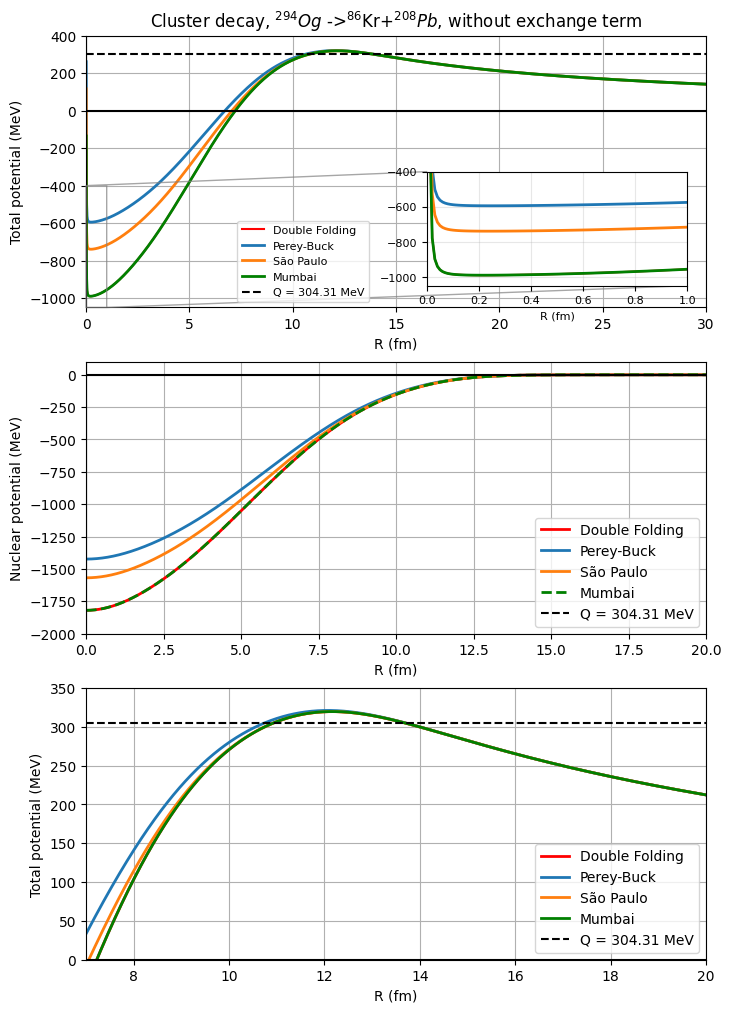

In [28]:
import matplotlib.pyplot as plt



fig, axs = plt.subplots(3, 1, figsize=(8, 12))

axs[0].plot(R_plot, VNN_plot + VC_plot + VL_plot, lw=1.5,color='red', label="Double Folding")
axs[0].plot(R_plot, UPB_plot + VC_plot + VL_plot, lw=2, label="Perey-Buck")
axs[0].plot(R_plot, USP_plot + VC_plot + VL_plot, lw=2, label="São Paulo")
axs[0].plot(R_plot, VM_plot + VC_plot + VL_plot, lw=2,color='green', label="Mumbai")
# Inset con zoom en r ∈ [0, 5] fm
axins = axs[0].inset_axes([0.55, 0.08, 0.42, 0.42])  # [x, y, w, h] en fracción de axs[0]
axins.plot(R_plot, VNN_plot + VC_plot + VL_plot, lw=1.5, color='red',   label="Double Folding")
axins.plot(R_plot, UPB_plot + VC_plot + VL_plot, lw=2,                  label="Perey-Buck")
axins.plot(R_plot, USP_plot + VC_plot + VL_plot, lw=2,                  label="São Paulo")
axins.plot(R_plot, VM_plot  + VC_plot + VL_plot, lw=2, color='green',   label="Mumbai")
axins.axhline(Q_plot, color='k', ls='--')
axins.set_xlim(0, 1)
axins.set_ylim(-1050,-400 )
# El ylim del inset se ajusta a lo que caiga en [0, 5] fm; podés fijarlo a mano si querés


axins.grid(True, alpha=0.3)
axins.set_xlabel("R (fm)", fontsize=8)
axins.tick_params(labelsize=8)

# Marca el recuadro sobre el gráfico principal y dibuja las líneas conectoras
axs[0].indicate_inset_zoom(axins, edgecolor="gray", alpha=0.7)
axs[0].axhline(Q_plot, color='k', ls='--', label=f"Q = {Q_plot:.2f} MeV")

axs[0].set_xlim(0,30)
axs[0].set_ylim(-1050,400)
axs[0].axhline(0, color='black', linewidth=1.5)
axs[0].axvline(0, color='black', linewidth=1.5)
axs[0].set_xlabel("R (fm)")
axs[0].set_ylabel("Total potential (MeV)")
axs[0].set_title('Cluster decay, $^{294}Og$ ->$^{86}$Kr+$^{208}Pb$, without exchange term')
axs[0].legend(fontsize=8, loc='lower center', bbox_to_anchor=(0.35, 0))

axs[0].grid(True)

#Nuclear
axs[1].plot(R_plot, VNN_plot , lw=2,  color='red', label="Double Folding")
axs[1].plot(R_plot, UPB_plot , lw=2, label="Perey-Buck")
axs[1].plot(R_plot, USP_plot , lw=2, label="São Paulo")
axs[1].plot(R_plot, VM_plot , lw=2, ls='--', color='green', label="Mumbai")

axs[1].axhline(Q_plot, color='k', ls='--', label=f"Q = {Q_plot:.2f} MeV")
axs[1].axhline(0, color='black', linewidth=1.5)
axs[1].axvline(0, color='black', linewidth=1.5)
axs[1].set_xlim(0,20)
axs[1].set_ylim(-2000,100)

axs[1].set_xlabel("R (fm)")
axs[1].set_ylabel("Nuclear potential (MeV)")
axs[1].legend()
axs[1].grid(True)

#Coulomb zoom
axs[2].plot(R_plot, VNN_plot + VC_plot + VL_plot, lw=2,  color='red', label="Double Folding")
axs[2].plot(R_plot, UPB_plot + VC_plot + VL_plot, lw=2, label="Perey-Buck")
axs[2].plot(R_plot, USP_plot + VC_plot + VL_plot, lw=2, label="São Paulo")
axs[2].plot(R_plot, VM_plot + VC_plot + VL_plot, lw=2,  color='green', label="Mumbai")
axs[2].axhline(Q_plot, color='k', ls='--', label=f"Q = {Q_plot:.2f} MeV")

axs[2].set_xlim(7,20)
axs[2].set_ylim(0,350)
axs[2].axhline(0, color='black', linewidth=1.5)
axs[2].axvline(0, color='black', linewidth=1.5)
axs[2].set_xlabel("R (fm)")
axs[2].set_ylabel("Total potential (MeV)")
axs[2].legend()
axs[2].grid(True)

plt.show()

In [ ]:
#Whit the exchange term, J00
import numpy as np
from scipy.integrate import quad, simpson
from scipy.interpolate import InterpolatedUnivariateSpline, interp1d
from scipy.optimize import brentq

# ─────────────────────────────────────────
#  DATASET: (nombre, Z_daughter, Z_cluster, A_daughter, A_cluster,Q, G, beta)
# ─────────────────────────────────────────
nuclei = [
    
    #("Ra-222", 82,  6, 208, 14, 33.049, 68,  0.0648),
    ("Cm-242", 82, 14, 208, 34, 96.509, 142, 0.0291)
    #("Cm-242", 82, 14, 208, 34, 96.509, 142, 0.0291)
]


# ─────────────────────────────────────────
#  CONSTANTES FIJAS
# ─────────────────────────────────────────

e2       = 1.44
a        = 0.54
x        = 7999 / 4
y        = 2134 / 2.5
J00      = -275
hbarc    = 197.327
hbar     = 6.582119569e-22
m_n      = 931.494
L        = 0


# Grillas globales
r_grid_c = np.linspace(0.01, 25,   2000)
r_grid_d = np.linspace(0.01, 25,   2000)
k_grid = np.linspace(0.0001, 30, 10000)
R_grid = np.linspace(0.01, 50,  5000)
#R_grid = np.linspace(0.01, 80,  5000)

# Transformada de Fourier del alfa (fija, no depende del núcleo hijo)


#-----------------------WHERE IS THE INTERCHANGE TERM ------------------------------------------------------------
g_NN = (x / (k_grid**2 + 4**2)) - (y / (k_grid**2 + 2.5**2)) #+  (J00 / (4 * np.pi))

def sinc_safe(k, r):
    kr = k * r
    return np.where(kr == 0, 1.0, np.sin(kr) / kr)
#------------------------------------------------------------------------------------------------------------------

# ─────────────────────────────────────────
#  FUNCIÓN: busca λ óptimo y calcula tau
# ─────────────────────────────────────────
def compute_tau(V_nuc, V_C, V_L, Q, mu, B, label=""):

    def action(lam):
        V = lam * V_nuc + V_C + V_L
        s = InterpolatedUnivariateSpline(R_grid, Q - V, k=3)
        roots = s.roots()
        if len(roots) < 3:
            return None
        r1, r2, r3 = roots[0], roots[1], roots[2]
        I_val = quad(
            lambda r: np.sqrt(np.maximum((2*mu/hbarc**2) * s(r), 0)),
            r1, r2, limit=1000, points=[r1, r2],
            epsabs=1e-6, epsrel=1e-6
        )[0]
        return I_val, r1, r2, r3

    vals = []
    for lam in np.linspace(0.3, 2, 3000):
        res = action(lam)
        if res is not None:
            vals.append((lam, *res))

    if not vals:
        print(f"  [{label}] No se encontró λ válido.")
        return None

    lam_opt, _, r1_opt, r2_opt, r3_opt = min(vals, key=lambda v: abs(v[1] - B))

    V_fun = interp1d(R_grid, lam_opt * V_nuc + V_C + V_L,
                     kind='cubic', fill_value="extrapolate")

    I_G = quad(
        lambda r: np.sqrt((2*mu/hbarc**2) * np.maximum(V_fun(r) - Q, 0)),
        r2_opt, r3_opt, limit=200, points=[r2_opt, r3_opt],
        epsabs=1e-4, epsrel=1e-4
    )[0]

    I_f = quad(
        lambda r: 1 / np.sqrt((2*mu/hbarc**2) * np.abs(V_fun(r) - Q)),
        r1_opt, r2_opt, limit=200, points=[r1_opt, r2_opt],
        epsabs=1e-4, epsrel=1e-4
    )[0]

    N     = 1 / I_f
    P     = np.exp(-2 * I_G)
    Gamma = (hbarc**2 * P * N) / (2 * mu)
    tau   = (hbar * np.log(2)) / Gamma

    return tau, lam_opt, r1_opt, r2_opt, r3_opt, P, N


# ─────────────────────────────────────────
#  FUNCIÓN PRINCIPAL POR NÚCLEO
# ─────────────────────────────────────────
def compute_nucleus(name, Z_d, Z_c, A_d, A_c, Q, G, beta):
    print(f"\n>>> Calculando Cluster decay {name}...")
    cd          = 1.07 * A_d**(1/3)
    cc          = 1.07 * A_c**(1/3)
    mu         = (A_d * A_c) / (A_d + A_c) * m_n
    B          = (G - L + 1) * (np.pi / 2)
    zpb        = (mu * beta**2) / (2 * hbarc**2)
    r3_Coulomb = (Z_c * Z_d * e2) / Q

    WSc = 1 / (1 + np.exp((r_grid_c - cc) / a))
    WSd = 1 / (1 + np.exp((r_grid_d - cd) / a))

    norm_NN_c = A_c / (4*np.pi * quad(lambda r: r**2 / (1 + np.exp((r-cc)/a)), 0, 25)[0])
    norm_C_c  = Z_c / (4*np.pi * quad(lambda r: r**2 / (1 + np.exp((r-cc)/a)), 0, 15)[0])
    norm_NN_d = A_d / (4*np.pi * quad(lambda r: r**2 / (1 + np.exp((r-cd)/a)), 0, 25)[0])
    norm_C_d  = Z_d / (4*np.pi * quad(lambda r: r**2 / (1 + np.exp((r-cd)/a)), 0, 15)[0])

    # Transformadas de Fourier del núcleo hijo
    rhoc_fnuclear = np.array([
        simpson(4*np.pi * norm_NN_c * r_grid_c**2 * sinc_safe(ki, r_grid_c) * WSc, r_grid_c)
        for ki in k_grid])

    rhoc_fcoulomb = np.array([
        simpson(4*np.pi * norm_C_c * r_grid_c**2 * sinc_safe(ki, r_grid_c) * WSc, r_grid_c)
        for ki in k_grid])
    
    rhod_fnuclear = np.array([
        simpson(4*np.pi * norm_NN_d * r_grid_d**2 * sinc_safe(ki, r_grid_d) * WSd, r_grid_d)
        for ki in k_grid])

    rhod_fcoulomb = np.array([
        simpson(4*np.pi * norm_C_d * r_grid_d**2 * sinc_safe(ki, r_grid_d) * WSd, r_grid_d)
        for ki in k_grid])

    # ── Potenciales base ──────────────────────────────────
    print("  Calculando V_NN, V_C, V_L...")
    V_NN = np.array([
        simpson((1/(2*np.pi**2)) * rhoc_fnuclear * rhod_fnuclear
                * sinc_safe(Ri, k_grid) * k_grid**2 * (4*np.pi*g_NN), k_grid)
        for Ri in R_grid])

    V_C = np.array([
        simpson((2*e2/np.pi) * rhoc_fcoulomb * rhod_fcoulomb
                * sinc_safe(Ri, k_grid), k_grid)
        for Ri in R_grid])

    V_L = (hbarc**2 / (2*mu)) * ((L + 0.5)**2 / R_grid**2)

    # ── 1) Double Folding ─────────────────────────────────
    print("  [1/4] Double Folding...")
    res_DF = compute_tau(V_NN, V_C, V_L, Q, mu, B, "DF")

    # ── 2) Perey-Buck ─────────────────────────────────────
    print("  [2/4] Perey-Buck...")
    U_PB = []
    for V_NNi in V_NN:
        try:
            U = brentq(lambda U, Ub: U * np.exp(zpb * (Q - U)) - Ub,
                       -2000, 300, args=(V_NNi,))
            U_PB.append(U)
        except ValueError:
            U_PB.append(np.nan)
    U_PB = np.array(U_PB)
    res_PB = compute_tau(U_PB, V_C, V_L, Q, mu, B, "PB")

    # ── 3) São Paulo ──────────────────────────────────────
    print("  [3/4] São Paulo...")
    U_SP = []
    for i, V_NNi in enumerate(V_NN):
        V_Ci = V_C[i]
        try:
            U = brentq(lambda U, Ub, Vc: U * np.exp(zpb * (Q - Vc - U)) - Ub,
                       -2000, 300, args=(V_NNi, V_Ci))
            U_SP.append(U)
        except ValueError:
            U_SP.append(np.nan)
    U_SP =  np.array(U_SP)
    res_SP = compute_tau(U_SP, V_C, V_L, Q, mu, B, "SP")

    # ── 4) Mumbai ─────────────────────────────────────────
    print("  [4/4] Mumbai...")
    VNN_spline = InterpolatedUnivariateSpline(R_grid, V_NN, k=3)
    V_M = []
    for rMi in R_grid:
        r_mid = (rMi + R_grid) / 2
        V_mid = VNN_spline(np.clip(r_mid, R_grid[0], R_grid[-1]))
        kernel = (np.exp(-((rMi - R_grid)**2) / beta**2)
                - np.exp(-((rMi + R_grid)**2) / beta**2))
        V_IM = (1 / (np.sqrt(np.pi) * beta)) * V_mid * kernel
        V_M.append(simpson(V_IM, R_grid))
    V_M = np.array(V_M)
    res_MU = compute_tau(V_M, V_C, V_L, Q, mu, B, "Mumbai")

    global VNN_plot, VC_plot, VL_plot, UPB_plot, USP_plot, VM_plot, R_plot, Q_plot

    VNN_plot = V_NN.copy()
    VC_plot  = V_C.copy()
    VL_plot  = V_L.copy()
    UPB_plot = U_PB.copy()
    USP_plot = U_SP.copy()
    VM_plot  = V_M.copy()
    R_plot   = R_grid.copy()
    Q_plot   = Q

    return name, r3_Coulomb, res_DF, res_PB, res_SP, res_MU


# ─────────────────────────────────────────
#  LOOP PRINCIPAL + TABLA
# ─────────────────────────────────────────
modelos = ["DF", "Perey-Buck", "São Paulo", "Mumbai"]

sep = "=" * 115
hdr = (f"{'Núcleo':<10}  {'Modelo':<12}  {'t½ (s)':>12}  {'λ':>6}"
       f"  {'r1 (fm)':>8}  {'r2 (fm)':>8}  {'r3 (fm)':>8}"
       f"  {'P':>12}  {'N':>6}  {'r3_C (fm)':>10}")

print("\n" + sep)
print(hdr)
print(sep)

for params in nuclei:
    name, r3C, *resultados = compute_nucleus(*params)
    for modelo, res in zip(modelos, resultados):
        if res:
            tau, lam, r1, r2, r3, P, N = res
            print(f"{name:<10}  {modelo:<12}  {tau:12.2e}  {lam:6.2f}"
                  f"  {r1:8.2f}  {r2:8.2f}  {r3:8.2f}"
                  f"  {P:12.2e}  {N:6.2f}  {r3C:10.2f}")
        else:
            print(f"{name:<10}  {modelo:<12}  {'--- sin solución ---':>12}")
    print("-" * 115)

print(sep + "\n")


Núcleo      Modelo              t½ (s)       λ   r1 (fm)   r2 (fm)   r3 (fm)             P       N   r3_C (fm)

>>> Calculando Cluster decay Cm-242...
  Calculando V_NN, V_C, V_L...
  [1/4] Double Folding...
  [2/4] Perey-Buck...
  [3/4] São Paulo...
  [4/4] Mumbai...
Cm-242      DF                7.52e+08    1.33      0.02      9.85     17.11      5.82e-31    1.46       17.13
Cm-242      Perey-Buck        2.96e+07    1.55      0.02     10.07     17.11      1.51e-29    1.43       17.13
Cm-242      São Paulo         6.02e+07    1.44      0.02     10.02     17.11      7.38e-30    1.44       17.13
Cm-242      Mumbai            7.24e+08    1.33      0.02      9.86     17.11      6.05e-31    1.46       17.13
-------------------------------------------------------------------------------------------------------------------



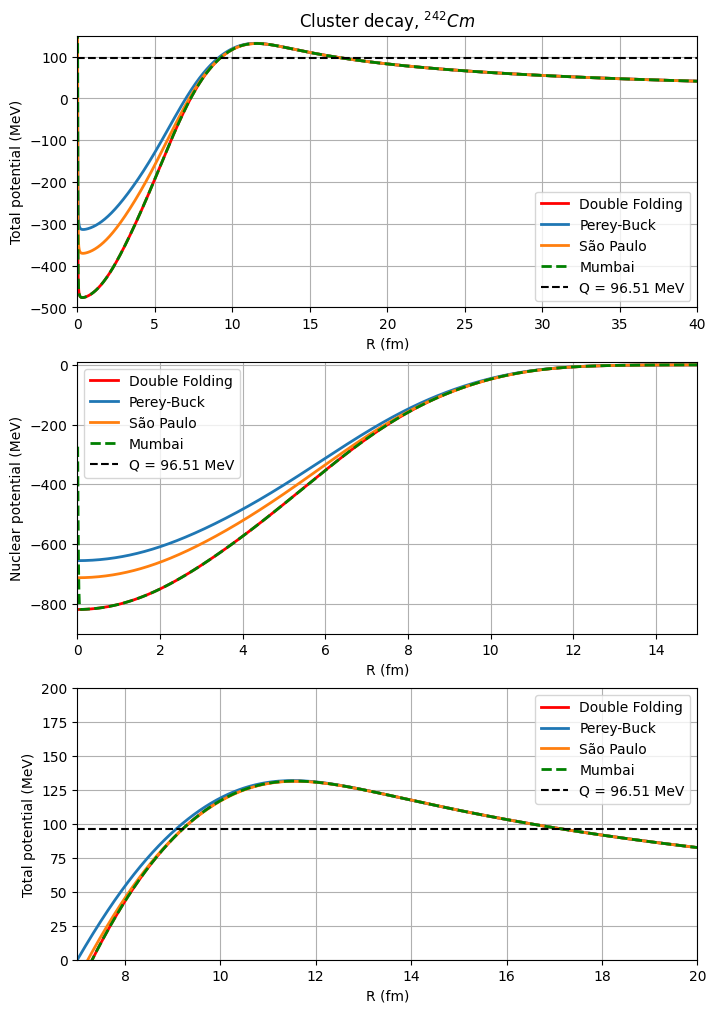

In [ ]:
import matplotlib.pyplot as plt



fig, axs = plt.subplots(3, 1, figsize=(8, 12))

axs[0].plot(R_plot, VNN_plot + VC_plot + VL_plot, lw=2,color='red', label="Double Folding")
axs[0].plot(R_plot, UPB_plot + VC_plot + VL_plot, lw=2, label="Perey-Buck")
axs[0].plot(R_plot, USP_plot + VC_plot + VL_plot, lw=2, label="São Paulo")
axs[0].plot(R_plot, VM_plot + VC_plot + VL_plot, lw=2, ls='--', color='green', label="Mumbai")

axs[0].axhline(Q_plot, color='k', ls='--', label=f"Q = {Q_plot:.2f} MeV")

axs[0].set_xlim(0,40)
axs[0].set_ylim(-500,150)
#axs[0].set_yscale('log')
axs[0].set_xlabel("R (fm)")
axs[0].set_ylabel("Total potential (MeV)")
axs[0].set_title('Cluster decay, $^{242}Cm$ ')
axs[0].legend()
axs[0].grid(True)
#Nuclear
axs[1].plot(R_plot, VNN_plot , lw=2,  color='red', label="Double Folding")
axs[1].plot(R_plot, UPB_plot , lw=2, label="Perey-Buck")
axs[1].plot(R_plot, USP_plot , lw=2, label="São Paulo")
axs[1].plot(R_plot, VM_plot , lw=2, ls='--', color='green', label="Mumbai")

axs[1].axhline(Q_plot, color='k', ls='--', label=f"Q = {Q_plot:.2f} MeV")

axs[1].set_xlim(0,15)
axs[1].set_ylim(-900,10)

axs[1].set_xlabel("R (fm)")
axs[1].set_ylabel("Nuclear potential (MeV)")
axs[1].legend()
axs[1].grid(True)

#Coulomb zoom
axs[2].plot(R_plot, VNN_plot + VC_plot + VL_plot, lw=2,  color='red', label="Double Folding")
axs[2].plot(R_plot, UPB_plot + VC_plot + VL_plot, lw=2, label="Perey-Buck")
axs[2].plot(R_plot, USP_plot + VC_plot + VL_plot, lw=2, label="São Paulo")
axs[2].plot(R_plot, VM_plot + VC_plot + VL_plot, lw=2, ls='--', color='green', label="Mumbai")
axs[2].axhline(Q_plot, color='k', ls='--', label=f"Q = {Q_plot:.2f} MeV")

axs[2].set_xlim(7,20)
axs[2].set_ylim(0,200)

axs[2].set_xlabel("R (fm)")
axs[2].set_ylabel("Total potential (MeV)")
axs[2].legend()
axs[2].grid(True)

plt.show()